<a href="https://colab.research.google.com/github/navya-illa/CMPE255-Assignments/blob/main/Assignment-3/Part1-KMeans/kmeans_variations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: K-Means and Its Variations
This notebook walks through k-means and several related clustering methods:
1. Vanilla k-means and choosing k (elbow and silhouette)
2. Initialization: random vs k-means++
3. MiniBatch k-means (speed vs quality)
4. Bisecting k-means
5. Gaussian Mixture Models (soft k-means)
6. Where k-means fails (non-spherical clusters) and alternatives
7. Real dataset: Wine, with scaling and evaluation against known labels

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans, MiniBatchKMeans, BisectingKMeans, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs, make_moons, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
print("scikit-learn", sklearn.__version__)
RS = 42

scikit-learn 1.6.1


## 1. Vanilla k-means and choosing k

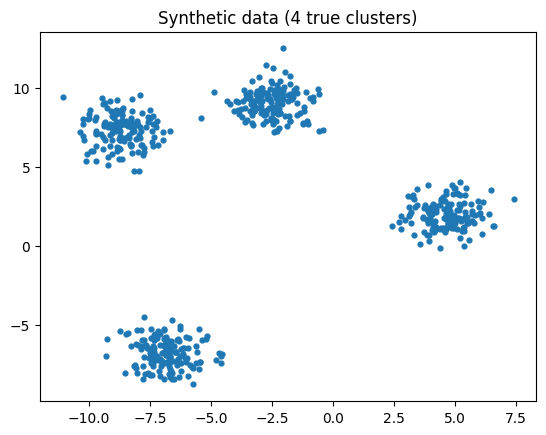

In [2]:
X, y_true = make_blobs(n_samples=600, centers=4, cluster_std=0.9, random_state=RS)

plt.scatter(X[:, 0], X[:, 1], s=12)
plt.title("Synthetic data (4 true clusters)")
plt.show()

The elbow method looks at inertia (within-cluster sum of squares). Silhouette measures how well separated clusters are (higher is better).

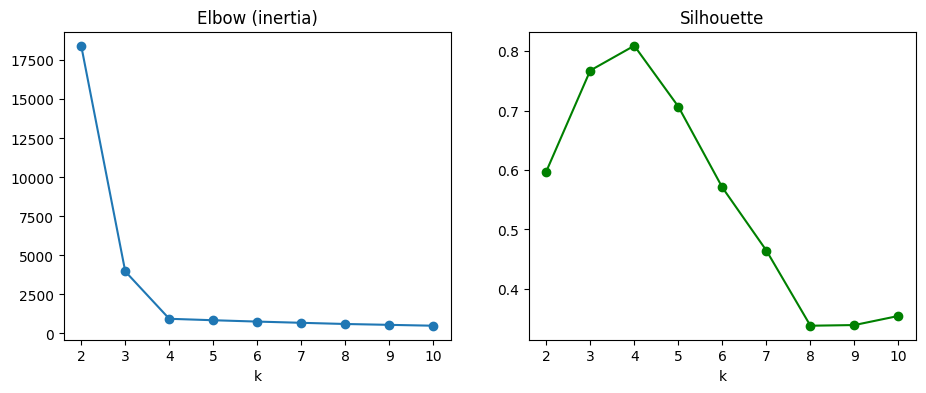

Best k by silhouette: 4


In [3]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RS).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sils, "o-", color="green"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
plt.show()
print("Best k by silhouette:", list(ks)[int(np.argmax(sils))])

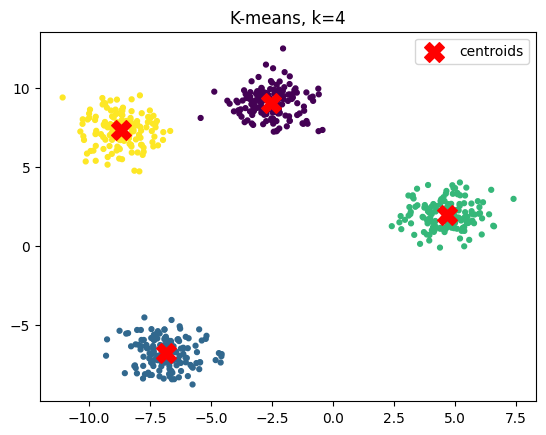

Inertia: 941.899086169201 | ARI vs truth: 1.0


In [4]:
km = KMeans(n_clusters=4, n_init=10, random_state=RS).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=km.labels_, s=12, cmap="viridis")
plt.scatter(*km.cluster_centers_.T, c="red", marker="X", s=200, label="centroids")
plt.legend(); plt.title("K-means, k=4"); plt.show()
print("Inertia:", km.inertia_, "| ARI vs truth:", adjusted_rand_score(y_true, km.labels_))

## 2. Initialization: random vs k-means++
With `n_init=1`, a bad initialization can land in a poor local minimum. We repeat over many seeds.

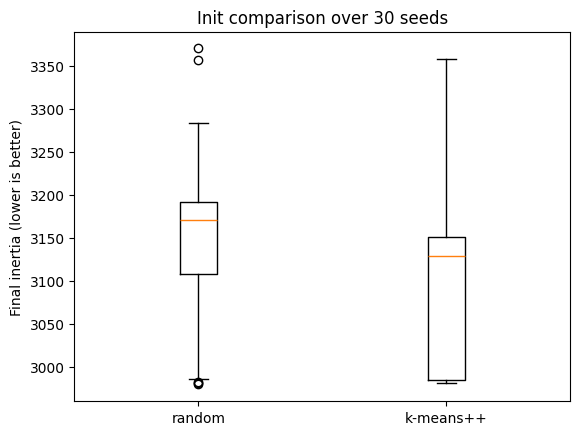

{'random': (np.float64(3147.8), np.float64(98.0)), 'k-means++': (np.float64(3093.0), np.float64(94.8))}


In [5]:
Xh, _ = make_blobs(n_samples=1500, centers=10, cluster_std=1.2, random_state=1)
res = {"random": [], "k-means++": []}
for seed in range(30):
    for name, init in [("random", "random"), ("k-means++", "k-means++")]:
        m = KMeans(n_clusters=10, init=init, n_init=1, random_state=seed).fit(Xh)
        res[name].append(m.inertia_)

plt.boxplot([res["random"], res["k-means++"]])
plt.xticks([1, 2], ["random", "k-means++"])
plt.ylabel("Final inertia (lower is better)"); plt.title("Init comparison over 30 seeds")
plt.show()
print({k: (round(np.mean(v), 1), round(np.std(v), 1)) for k, v in res.items()})

## 3. MiniBatch k-means: speed vs quality

In [6]:
Xbig, _ = make_blobs(n_samples=200_000, centers=8, cluster_std=1.5, random_state=RS)

t = time.time(); full = KMeans(n_clusters=8, n_init=3, random_state=RS).fit(Xbig); t_full = time.time() - t
t = time.time(); mini = MiniBatchKMeans(n_clusters=8, n_init=3, batch_size=2048, random_state=RS).fit(Xbig); t_mini = time.time() - t

print(f"KMeans          time={t_full:.2f}s inertia={full.inertia_:.0f}")
print(f"MiniBatchKMeans time={t_mini:.2f}s inertia={mini.inertia_:.0f}")

KMeans          time=1.45s inertia=734363
MiniBatchKMeans time=0.27s inertia=768912


## 4. Bisecting k-means
Starts with one cluster and repeatedly splits the largest (or highest-error) cluster in two. It gives a hierarchy-like result and is often more balanced.

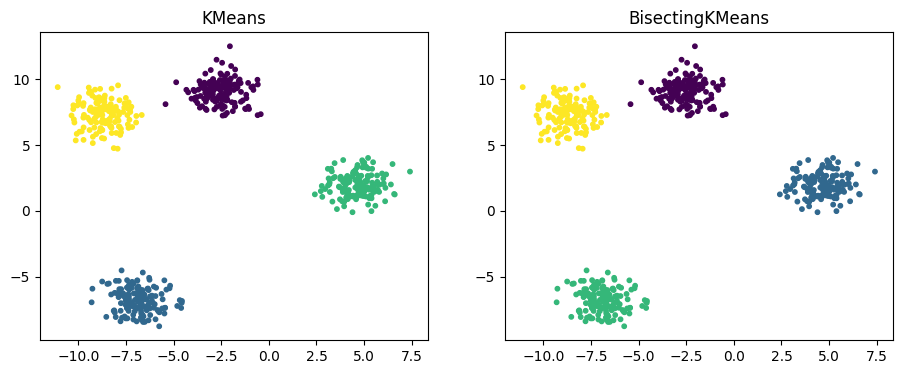

Silhouette KMeans: 0.8093224703839536 | Bisecting: 0.8093224703839536


In [7]:
bk = BisectingKMeans(n_clusters=4, random_state=RS).fit(X)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X[:, 0], X[:, 1], c=km.labels_, s=10); ax[0].set_title("KMeans")
ax[1].scatter(X[:, 0], X[:, 1], c=bk.labels_, s=10); ax[1].set_title("BisectingKMeans")
plt.show()
print("Silhouette KMeans:", silhouette_score(X, km.labels_), "| Bisecting:", silhouette_score(X, bk.labels_))

## 5. Gaussian Mixture Model (soft assignments)
K-means gives hard labels and assumes spherical clusters. A GMM gives each point a probability for each cluster and allows elliptical shapes.

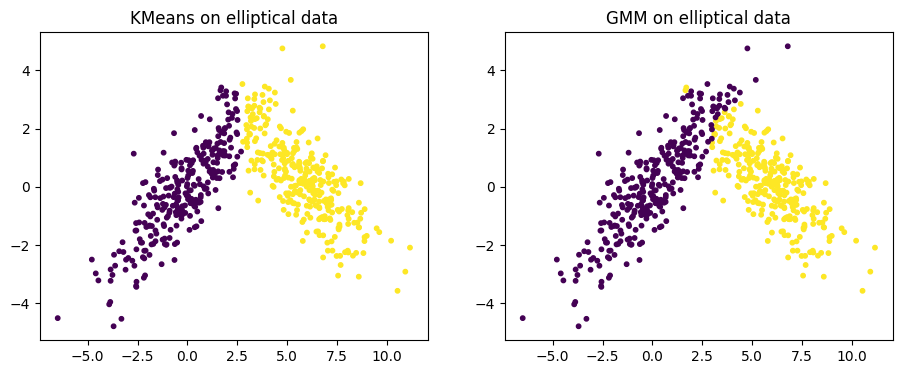

Soft probabilities for first 3 points:
 [[1. 0.]
 [1. 0.]
 [1. 0.]]


In [8]:
rng = np.random.RandomState(RS)
Xe = np.vstack([
    rng.multivariate_normal([0, 0], [[4, 3], [3, 3]], 300),
    rng.multivariate_normal([6, 0], [[3, -2], [-2, 2]], 300),
])
km_e = KMeans(2, n_init=10, random_state=RS).fit(Xe)
gm_e = GaussianMixture(2, covariance_type="full", random_state=RS).fit(Xe)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(Xe[:, 0], Xe[:, 1], c=km_e.labels_, s=10); ax[0].set_title("KMeans on elliptical data")
ax[1].scatter(Xe[:, 0], Xe[:, 1], c=gm_e.predict(Xe), s=10); ax[1].set_title("GMM on elliptical data")
plt.show()
print("Soft probabilities for first 3 points:\n", gm_e.predict_proba(Xe[:3]).round(3))

## 6. Where k-means fails: non-convex clusters

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


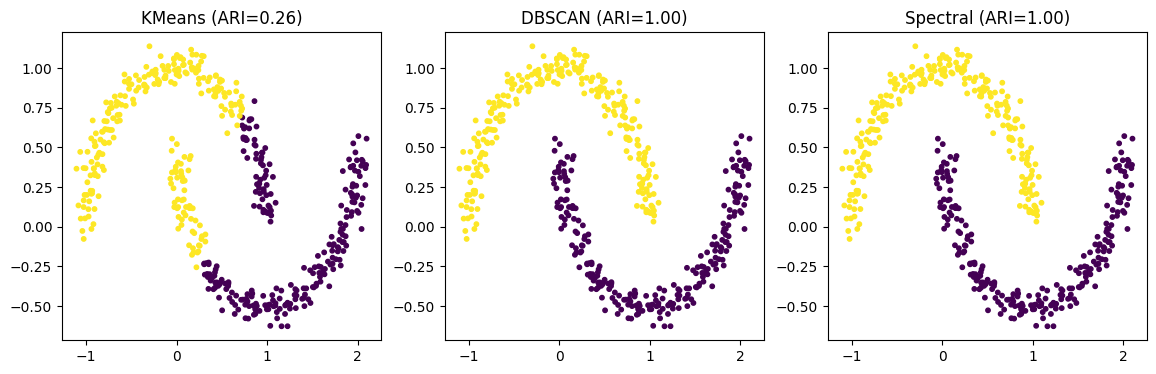

In [9]:
Xm, ym = make_moons(n_samples=500, noise=0.06, random_state=RS)
models = {
    "KMeans": KMeans(2, n_init=10, random_state=RS),
    "DBSCAN": DBSCAN(eps=0.2, min_samples=5),
    "Spectral": SpectralClustering(2, affinity="nearest_neighbors", random_state=RS),
}
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, (name, m) in zip(ax, models.items()):
    lab = m.fit_predict(Xm)
    a.scatter(Xm[:, 0], Xm[:, 1], c=lab, s=10); a.set_title(f"{name} (ARI={adjusted_rand_score(ym, lab):.2f})")
plt.show()

## 7. Real dataset: Wine
Features are on very different scales, so scaling matters for distance-based methods.

In [10]:
wine = load_wine()
Xw, yw = wine.data, wine.target
Xw_s = StandardScaler().fit_transform(Xw)

raw = KMeans(3, n_init=10, random_state=RS).fit(Xw)
scaled = KMeans(3, n_init=10, random_state=RS).fit(Xw_s)
print("ARI without scaling:", round(adjusted_rand_score(yw, raw.labels_), 3))
print("ARI with scaling:   ", round(adjusted_rand_score(yw, scaled.labels_), 3))

ARI without scaling: 0.371
ARI with scaling:    0.897


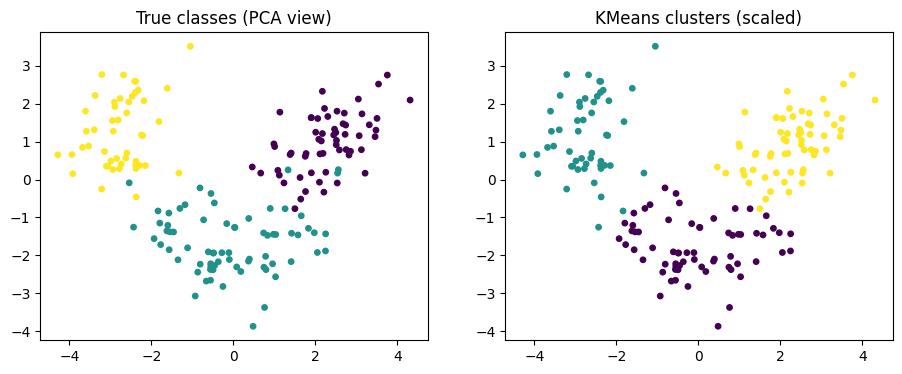

In [11]:
Z = PCA(2, random_state=RS).fit_transform(Xw_s)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(Z[:, 0], Z[:, 1], c=yw, s=15); ax[0].set_title("True classes (PCA view)")
ax[1].scatter(Z[:, 0], Z[:, 1], c=scaled.labels_, s=15); ax[1].set_title("KMeans clusters (scaled)")
plt.show()

In [12]:
rows = []
for name, m in [("KMeans", KMeans(3, n_init=10, random_state=RS)),
                ("MiniBatchKMeans", MiniBatchKMeans(3, n_init=10, random_state=RS)),
                ("BisectingKMeans", BisectingKMeans(3, random_state=RS)),
                ("GaussianMixture", GaussianMixture(3, random_state=RS))]:
    t = time.time(); lab = m.fit_predict(Xw_s); dt = time.time() - t
    rows.append([name, silhouette_score(Xw_s, lab), adjusted_rand_score(yw, lab), dt])
pd.DataFrame(rows, columns=["method", "silhouette", "ARI", "seconds"]).round(4)

,method,silhouette,ARI,seconds
0,KMeans,0.2849,0.8975,0.0376
1,MiniBatchKMeans,0.2837,0.9121,0.0703
2,BisectingKMeans,0.2659,0.6909,0.0049
3,GaussianMixture,0.2849,0.8975,0.0508


## Takeaways
- Choose k using several signals (elbow, silhouette), not just one.
- k-means++ init gives lower and more stable inertia than random init.
- MiniBatch trades a little quality for large speedups on big data.
- GMM handles elliptical clusters and gives soft assignments; DBSCAN and spectral handle non-convex shapes.
- Always scale features before distance-based clustering.